# Forget-set ROUGE Comparison across Unlearning Methods
Loads per-sample ROUGE scores from each method's `evals/TOFU_EVAL.json` and
produces a boxplot comparable to `analysis_out/RMU_forget10/rouge_comparison.png`.

In [58]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [59]:
# ── Config ────────────────────────────────────────────────────────────────────
SAVES   = Path('saves')
OUT_DIR = Path('analysis_out/RMU_forget10')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL = 'Llama-3.2-1B-Instruct'
SPLIT = 'forget01'

# (display_name, path_to_eval_json)
METHODS = [
    ('Retrained',  SAVES / f'eval/tofu_{MODEL}_retain90/TOFU_EVAL.json'),
    ('GradAscent', SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_GradAscent/evals/TOFU_EVAL.json'),
    ('GradDiff',   SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_GradDiff/evals/TOFU_EVAL.json'),
    ('NPO',        SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_NPO/evals/TOFU_EVAL.json'),
    ('RMU',        SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_RMU/evals/TOFU_EVAL.json'),
    ('SimNPO',     SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_SimNPO/evals/TOFU_EVAL.json'),
    ('Ours',       SAVES / f'unlearn/tofu_{MODEL}_{SPLIT}_LatentRMU_v4.8_sweep/checkpoint-120/evals/TOFU_EVAL.json'),
]

# Color palette: muted for baselines, vivid red for Ours
PALETTE = {
    'Retrained': '#1a9641',  # oracle green
    'GradAscent': '#aec7e8',
    'GradDiff':   '#ffbb78',
    'NPO':        '#c5b0d5',
    'RMU':        '#98df8a',
    'SimNPO':     '#c49c94',
    'Ours':       '#d62728',
}

# Metrics available in value_by_index dicts
METRICS = [
    ('rouge1_recall', 'ROUGE-1 Recall'),
    ('rougeL_recall', 'ROUGE-L Recall'),
    ('rougeL_f1',     'ROUGE-L F1'),
]

In [60]:
def load_per_sample_rouge(eval_path, eval_key):
    """Return a list of per-sample metric dicts from TOFU_EVAL.json."""
    with open(eval_path) as f:
        data = json.load(f)
    by_index = data[eval_key]['value_by_index']   # {str_idx: {metric: float, ...}}
    return [by_index[str(i)] for i in range(len(by_index))]


EVAL_KEY = 'forget_Q_A_ROUGE'

method_rouge = {}
for name, path in METHODS:
    if not path.exists():
        print(f'MISSING: {name}  ({path})')
        continue
    method_rouge[name] = load_per_sample_rouge(path, EVAL_KEY)
    n   = len(method_rouge[name])
    agg = {m: np.mean([r[m] for r in method_rouge[name]]) for m, _ in METRICS}
    print(f'{name:12s}  n={n}  ' + '  '.join(f'{lbl}={v:.3f}' for (_, lbl), v in zip(METRICS, agg.values())))

Retrained     n=400  ROUGE-1 Recall=0.457  ROUGE-L Recall=0.379  ROUGE-L F1=0.371
GradAscent    n=40  ROUGE-1 Recall=0.257  ROUGE-L Recall=0.205  ROUGE-L F1=0.192
GradDiff      n=40  ROUGE-1 Recall=0.300  ROUGE-L Recall=0.241  ROUGE-L F1=0.226
NPO           n=40  ROUGE-1 Recall=0.389  ROUGE-L Recall=0.310  ROUGE-L F1=0.315
RMU           n=40  ROUGE-1 Recall=0.212  ROUGE-L Recall=0.165  ROUGE-L F1=0.131
SimNPO        n=40  ROUGE-1 Recall=0.772  ROUGE-L Recall=0.739  ROUGE-L F1=0.734
Ours          n=40  ROUGE-1 Recall=0.171  ROUGE-L Recall=0.159  ROUGE-L F1=0.222


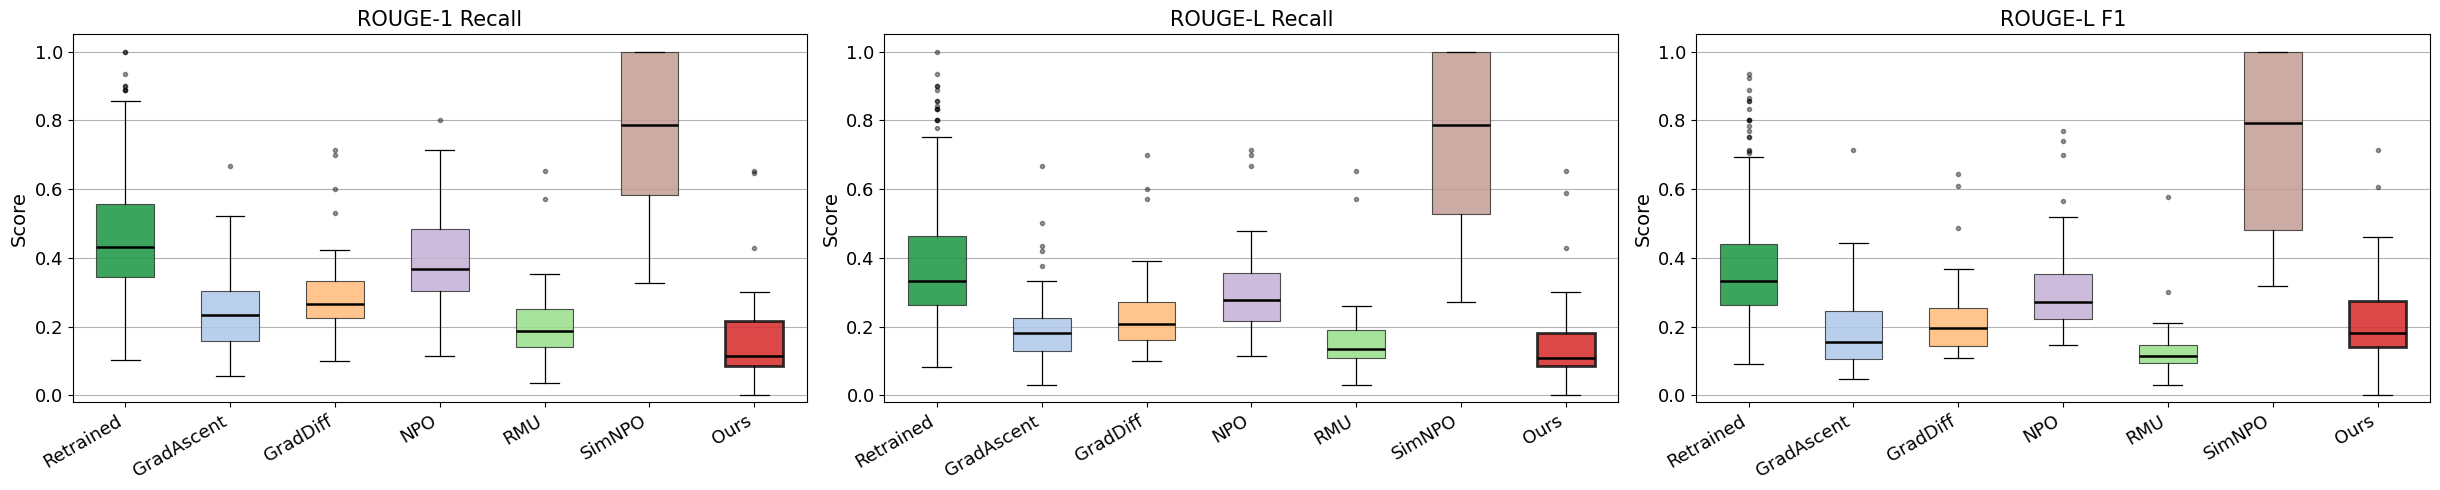

Saved: analysis_out/RMU_forget10/rouge_comparison_evals.pdf
Saved: analysis_out/RMU_forget10/rouge_comparison_evals.png


In [61]:
def plot_rouge_comparison(method_rouge, metrics, palette, out_path,
                          title=None):
    names     = list(method_rouge.keys())
    n_methods = len(names)
    n_metrics = len(metrics)

    plt.rcParams.update({
        'text.color':        'black',
        'axes.labelcolor':   'black',
        'xtick.color':       'black',
        'ytick.color':       'black',
        'axes.edgecolor':    'black',
    })

    fig, axes = plt.subplots(1, n_metrics,
                             figsize=(max(12, 3.5 * n_methods), 5),
                             sharey=False)
    if n_metrics == 1:
        axes = [axes]

    for ax, (metric_key, metric_label) in zip(axes, metrics):
        data        = [[r[metric_key] for r in method_rouge[n]] for n in names]
        colors      = [palette.get(n, '#bbbbbb') for n in names]
        edge_colors = ['#111111' if n == 'Ours' else '#333333' for n in names]
        lws         = [2.0 if n == 'Ours' else 0.8 for n in names]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.55,
            medianprops=dict(color='black', linewidth=1.8),
            flierprops=dict(marker='o', markersize=3, alpha=0.4,
                            markerfacecolor='black', markeredgecolor='black'),
            whiskerprops=dict(color='black', linewidth=0.9),
            capprops=dict(color='black', linewidth=0.9),
        )
        for patch, c, ec, lw in zip(bp['boxes'], colors, edge_colors, lws):
            patch.set_facecolor(c)
            patch.set_alpha(0.85)
            patch.set_edgecolor(ec)
            patch.set_linewidth(lw)

        ax.set_xticks(range(1, n_methods + 1))
        ax.set_xticklabels(names, rotation=30, ha='right',
                           fontsize=13, color='black')
        ax.set_title(metric_label, fontsize=15, color='black', pad=6)
        ax.set_ylabel('Score', fontsize=14, color='black')
        ax.tick_params(axis='y', labelsize=13, colors='black')
        ax.set_ylim(-0.02, 1.05)
        ax.grid(axis='y', alpha=0.3, color='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

    fig.tight_layout()
    # Save as PDF at 600 dpi
    pdf_path = out_path.with_suffix('.pdf')
    fig.savefig(pdf_path, dpi=600, bbox_inches='tight', format='pdf')
    fig.savefig(out_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {pdf_path}')
    print(f'Saved: {out_path}')


plot_rouge_comparison(
    method_rouge, METRICS, PALETTE,
    OUT_DIR / 'rouge_comparison_evals.png',
)


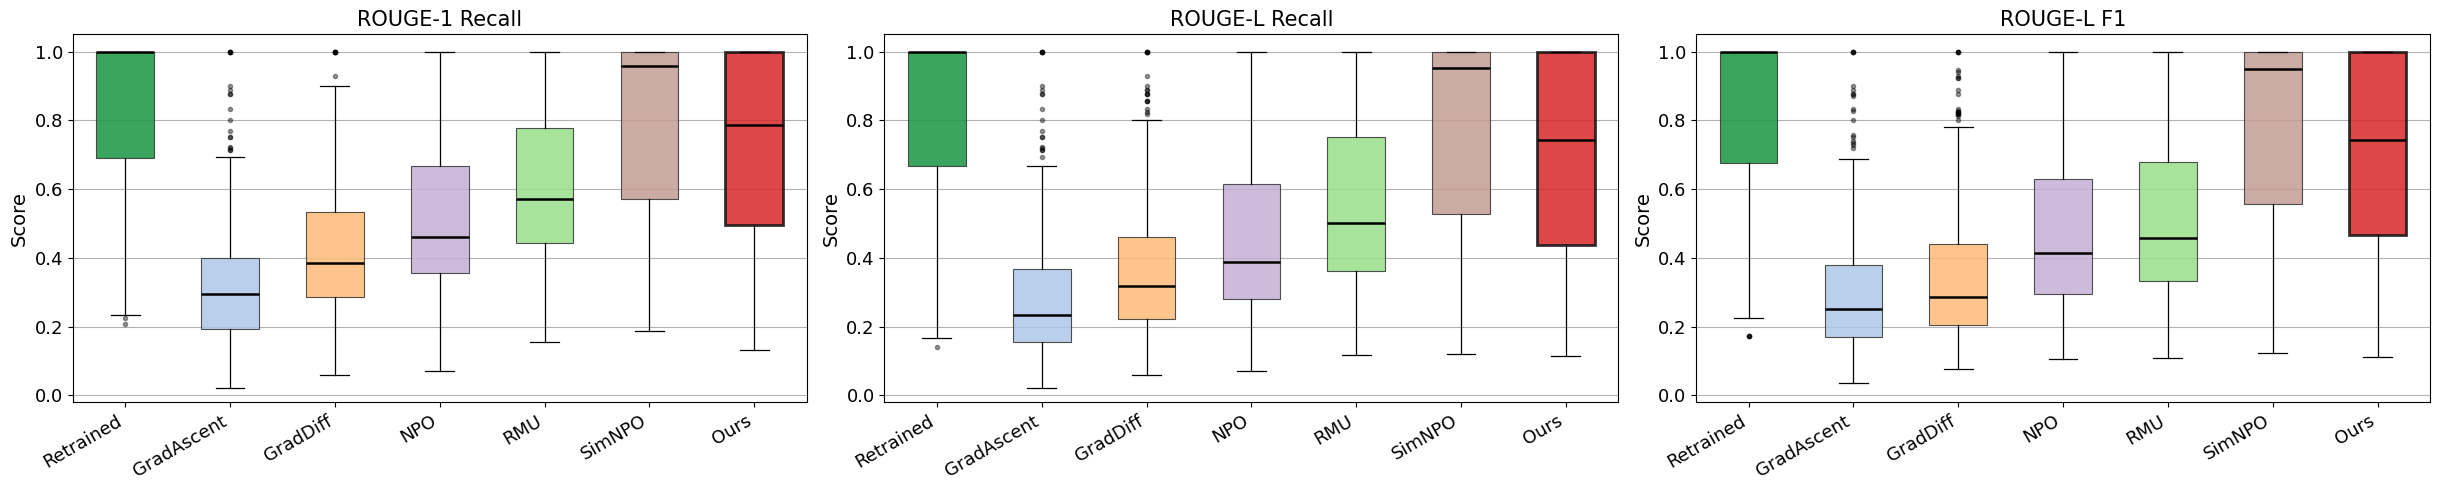

Saved: analysis_out/RMU_forget10/rouge_comparison_retain_evals.pdf
Saved: analysis_out/RMU_forget10/rouge_comparison_retain_evals.png


In [62]:
# ── Optional: retain-set ROUGE (model utility check) ─────────────────────────
method_rouge_retain = {}
for name, path in METHODS:
    if not path.exists():
        continue
    with open(path) as f:
        data = json.load(f)
    key = 'retain_Q_A_ROUGE'
    if key not in data:
        continue
    by_index = data[key]['value_by_index']
    method_rouge_retain[name] = [by_index[str(i)] for i in range(len(by_index))]

if method_rouge_retain:
    plot_rouge_comparison(
        method_rouge_retain, METRICS, PALETTE,
        OUT_DIR / 'rouge_comparison_retain_evals.png',
        title='Retain-set ROUGE Comparison across Methods',
    )

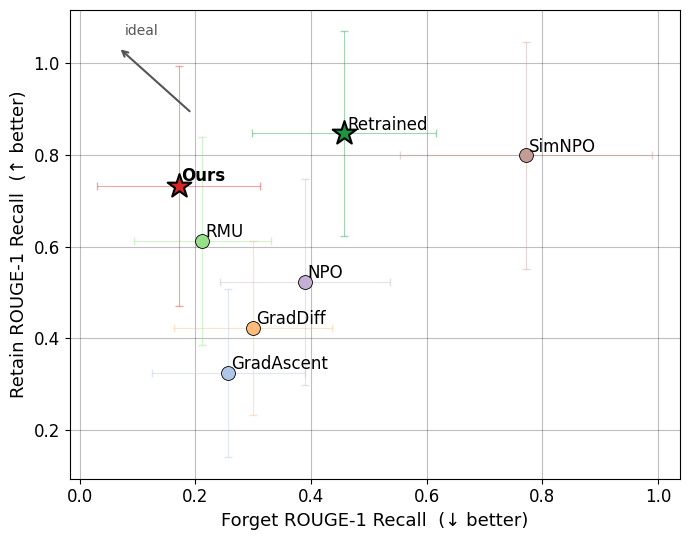

Saved: analysis_out/RMU_forget10/tradeoff_scatter.pdf
Saved: analysis_out/RMU_forget10/tradeoff_scatter.png


In [63]:
# ── Forget / Retain tradeoff scatter ────────────────────────────────────────
# Each method = one point. x = forget ROUGE (↓ better), y = retain ROUGE (↑ better).
# Top-left corner is ideal: low forget recall, high retain recall.

def plot_tradeoff_scatter(
    method_rouge_forget,
    method_rouge_retain,
    palette,
    out_path,
    metric_key='rouge1_recall',
    xlabel='Forget ROUGE-1 Recall  (↓ better)',
    ylabel='Retain ROUGE-1 Recall  (↑ better)',
):
    plt.rcParams.update({
        'text.color': 'black', 'axes.labelcolor': 'black',
        'xtick.color': 'black', 'ytick.color': 'black',
        'axes.edgecolor': 'black',
    })

    names = [n for n in method_rouge_forget if n in method_rouge_retain]

    fig, ax = plt.subplots(figsize=(7, 5.5))

    for name in names:
        f_vals = [r[metric_key] for r in method_rouge_forget[name]]
        r_vals = [r[metric_key] for r in method_rouge_retain[name]]
        f_mean, f_std = float(np.mean(f_vals)), float(np.std(f_vals))
        r_mean, r_std = float(np.mean(r_vals)), float(np.std(r_vals))

        is_ours      = name == 'Ours'
        is_retrained = name == 'Retrained'
        marker = '*' if (is_ours or is_retrained) else 'o'
        size   = 320 if (is_ours or is_retrained) else 100
        zorder = 5 if (is_ours or is_retrained) else 3
        lw     = 1.5 if (is_ours or is_retrained) else 0.6
        c      = palette.get(name, '#999999')

        # Error bars (±1 std)
        ax.errorbar(f_mean, r_mean,
                    xerr=f_std, yerr=r_std,
                    fmt='none', color=c, alpha=0.4, linewidth=0.8, capsize=3)

        ax.scatter(f_mean, r_mean,
                   c=c, marker=marker, s=size,
                   edgecolors='black', linewidths=lw,
                   zorder=zorder, label=name)

        # Label offset: push Ours label up, others slightly
        offset = (0.005, 0.012) if is_ours else (0.005, 0.008)
        ax.annotate(name, xy=(f_mean, r_mean),
                    xytext=(f_mean + offset[0], r_mean + offset[1]),
                    fontsize=12, color='black',
                    fontweight='bold' if is_ours else 'normal')

    # Shade the ideal quadrant (low forget, high retain)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_xlim(xlim); ax.set_ylim(ylim)

    ax.set_xlabel(xlabel, fontsize=13, color='black')
    ax.set_ylabel(ylabel, fontsize=13, color='black')
    ax.tick_params(labelsize=12, colors='black')
    ax.grid(True, alpha=0.25, color='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

    # Arrow annotation showing ideal direction
    ax.annotate('', xy=(0.08, 0.92), xytext=(0.20, 0.78),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
    ax.text(0.09, 0.94, 'ideal', transform=ax.transAxes,
            fontsize=10, color='#555555', va='bottom')

    fig.tight_layout()
    pdf_path = out_path.with_suffix('.pdf')
    fig.savefig(pdf_path, dpi=600, bbox_inches='tight', format='pdf')
    fig.savefig(out_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {pdf_path}')
    print(f'Saved: {out_path}')


# Build retain dict the same way as the forget dict
method_rouge_retain2 = {}
for name, path in METHODS:
    if not Path(path).exists():
        continue
    with open(path) as f:
        data = json.load(f)
    key = 'retain_Q_A_ROUGE'
    if key not in data:
        continue
    by_index = data[key]['value_by_index']
    method_rouge_retain2[name] = [by_index[str(i)] for i in range(len(by_index))]

plot_tradeoff_scatter(
    method_rouge, method_rouge_retain2, PALETTE,
    OUT_DIR / 'tradeoff_scatter.png',
)


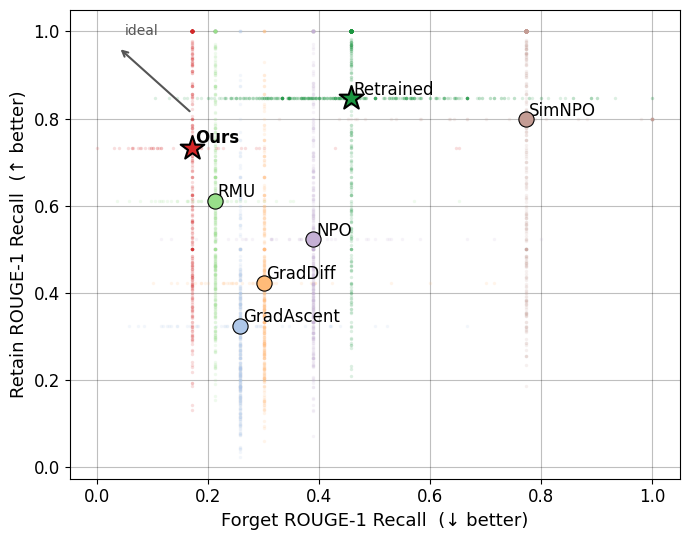

Saved: analysis_out/RMU_forget10/tradeoff_scatter_full.pdf
Saved: analysis_out/RMU_forget10/tradeoff_scatter_full.png


In [64]:
# ── Forget / Retain tradeoff scatter — all samples + centroid ────────────────
# forget and retain are different sets so can't be paired as (x,y).
# Instead: forget samples are drawn as a strip along x at the method's mean retain
# value; retain samples as a strip along y at the method's mean forget value.
# The centroid (mean, mean) is overlaid as the summary marker.

def plot_tradeoff_scatter_full(
    method_rouge_forget,
    method_rouge_retain,
    palette,
    out_path,
    metric_key='rouge1_recall',
    xlabel='Forget ROUGE-1 Recall  (↓ better)',
    ylabel='Retain ROUGE-1 Recall  (↑ better)',
):
    plt.rcParams.update({
        'text.color': 'black', 'axes.labelcolor': 'black',
        'xtick.color': 'black', 'ytick.color': 'black',
        'axes.edgecolor': 'black',
    })

    names = [n for n in method_rouge_forget if n in method_rouge_retain]

    fig, ax = plt.subplots(figsize=(7, 5.5))

    for name in names:
        f_vals = [r[metric_key] for r in method_rouge_forget[name]]
        r_vals = [r[metric_key] for r in method_rouge_retain[name]]
        f_mean = float(np.mean(f_vals))
        r_mean = float(np.mean(r_vals))

        is_ours      = name == 'Ours'
        is_retrained = name == 'Retrained'
        c = palette.get(name, '#999999')

        # Forget samples — strip along x at mean retain y
        ax.scatter(f_vals, [r_mean] * len(f_vals),
                   c=c, s=6, alpha=0.15, linewidths=0, zorder=2)

        # Retain samples — strip along y at mean forget x
        ax.scatter([f_mean] * len(r_vals), r_vals,
                   c=c, s=6, alpha=0.15, linewidths=0, zorder=2)

        # Centroid — larger, opaque
        marker = '*' if (is_ours or is_retrained) else 'o'
        size   = 320 if (is_ours or is_retrained) else 120
        lw     = 1.5 if (is_ours or is_retrained) else 0.8
        ax.scatter(f_mean, r_mean,
                   c=c, marker=marker, s=size,
                   edgecolors='black', linewidths=lw,
                   zorder=5, label=name)

        offset = (0.005, 0.012) if is_ours else (0.005, 0.008)
        ax.annotate(name, xy=(f_mean, r_mean),
                    xytext=(f_mean + offset[0], r_mean + offset[1]),
                    fontsize=12, color='black',
                    fontweight='bold' if is_ours else 'normal')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_xlim(xlim); ax.set_ylim(ylim)

    ax.set_xlabel(xlabel, fontsize=13, color='black')
    ax.set_ylabel(ylabel, fontsize=13, color='black')
    ax.tick_params(labelsize=12, colors='black')
    ax.grid(True, alpha=0.25, color='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

    ax.annotate('', xy=(0.08, 0.92), xytext=(0.20, 0.78),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
    ax.text(0.09, 0.94, 'ideal', transform=ax.transAxes,
            fontsize=10, color='#555555', va='bottom')

    fig.tight_layout()
    pdf_path = out_path.with_suffix('.pdf')
    fig.savefig(pdf_path, dpi=600, bbox_inches='tight', format='pdf')
    fig.savefig(out_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {pdf_path}')
    print(f'Saved: {out_path}')


plot_tradeoff_scatter_full(
    method_rouge, method_rouge_retain2, PALETTE,
    OUT_DIR / 'tradeoff_scatter_full.png',
)
